# Post-Hoc Analysis Pipeline
### Katherine (ZhaoYu) Tu — Master Thesis
**University of Amsterdam, 2026**

This notebook contains all post-hoc analyses for SRQ1 and SRQ3.
Run cells in order. All outputs are saved to the `results/` folder.

---
**SRQ1 analyses:**
- Accuracy summary table
- Confusion matrices (per model, per task), deeper analysis check `post_hoc_deep_analysis.ipynb`
    1. Relative major/minor confusion analysis
    2. Enharmonic equivalence errors
    3. Accidental direction errors (sharp vs flat confusion)
    4. Error distance in the circle of fifths
    5. Per-model error overlap
- Per-class accuracy (which keys/time sigs are hardest)
- Cross-model agreement (Definition A)

**SRQ3 analyses:**
- Accuracy summary table
- McNemar's test (PDF vs PNG, per model per task)
- Format effect direction (when they disagreed, which format was right?)
- Confusion matrices (per model, per task, per format)
- Per-class accuracy delta (PDF vs PNG)
- Cross-format consistency (Definition B)

---
## Cell 1 — Imports, config, shared helpers

In [2]:
%pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 11.1 MB/s  0:00:00m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python3.14 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import json
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_fscore_support
from statsmodels.stats.contingency_tables import mcnemar

warnings.filterwarnings("ignore")


In [16]:
# ── PATHS ─────────────────────────────────────────────────────────────────────
BASE_DIR    = Path("/Users/katherine.tu/Master Thesis/beethoven_piano_sonatas")
RESULTS_DIR = BASE_DIR / "results"

SRQ1_FILE = RESULTS_DIR / "srq1_results_fixed.jsonl"
SRQ3_FILE = RESULTS_DIR / "srq3_results.jsonl"

# ── CONSTANTS ─────────────────────────────────────────────────────────────────
MODELS = ["claude-sonnet-4-6", "gemini-2.5-flash", "gpt-5.4"]
TASKS  = ["key_signature", "time_signature"]

# ── SHARED KEY NORMALISATION HELPERS ─────────────────────────────────────────
# Copied from pipeline notebook so this notebook is self-contained.

def dcml_key_to_standard(dcml_key):
    """'F' → ('f','major'),  'f' → ('f','minor'),  'Bb' → ('bb','major')"""
    if not dcml_key:
        return None, None
    quality = "major" if dcml_key[0].isupper() else "minor"
    return dcml_key.lower(), quality

def normalise_key_for_comparison(raw_key):
    """Normalise a model response string to (note, quality) tuple."""
    if not raw_key:
        return None, None
    raw = raw_key.strip()
    if len(raw) <= 3 and " " not in raw:
        return dcml_key_to_standard(raw)
    raw_lower = raw.lower()
    if "major" in raw_lower or "maj" in raw_lower:
        quality = "major"
    elif "minor" in raw_lower or "min" in raw_lower:
        quality = "minor"
    else:
        quality = "major"
    note = raw_lower
    for word in ["major", "minor", "maj", "min"]:
        note = note.replace(word, "")
    note = note.strip().rstrip("-").strip()
    note = note.replace("flat", "b").replace("sharp", "#")
    note = note.replace("\u266d", "b").replace("\u266f", "#")
    note = note.replace("-", "").replace(" ", "")
    return note, quality

def keys_match(ground_truth_val, parsed_answer):
    if not ground_truth_val or not parsed_answer:
        return False
    gt_note, gt_quality     = dcml_key_to_standard(str(ground_truth_val))
    pred_note, pred_quality = normalise_key_for_comparison(parsed_answer)
    return gt_note == pred_note and gt_quality == pred_quality

def normalise_for_sklearn(val, question_type):
    """Normalise to a single comparable string for sklearn."""
    if not val or str(val).strip() == "":
        return "unknown"
    val = str(val).strip()
    if question_type == "key_signature":
        if len(val) <= 3 and " " not in val:
            note, quality = dcml_key_to_standard(val)
            if note and quality:
                return f"{note} {quality}"
        note, quality = normalise_key_for_comparison(val)
        if note and quality:
            return f"{note} {quality}"
        return val.lower()
    return val.lower().strip()

# ── LOADER ────────────────────────────────────────────────────────────────────

def load_jsonl(filepath):
    """Load a JSONL file into a DataFrame."""
    records = []
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    df = pd.DataFrame(records)
    print(f"Loaded {len(df)} entries from {Path(filepath).name}")
    print(f"Error rate: {(df['model_response'] == 'ERROR').mean():.1%}")
    return df

# ── METRIC CALCULATOR ─────────────────────────────────────────────────────────

def compute_metrics(df_subset, question_type):
    """Compute accuracy + macro P/R/F1 for a results subset."""
    df_clean = df_subset[df_subset["model_response"] != "ERROR"].copy()
    if df_clean.empty:
        return {"n": 0, "n_errors": len(df_subset),
                "accuracy": None, "precision": None,
                "recall": None, "f1": None}
    y_true = df_clean["ground_truth"].apply(
        lambda x: normalise_for_sklearn(x, question_type))
    y_pred = df_clean["parsed_answer"].fillna("").apply(
        lambda x: normalise_for_sklearn(x, question_type))
    accuracy = df_clean["correct"].mean()
    p, r, f, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0)
    return {"n": len(df_clean),
            "n_errors": len(df_subset) - len(df_clean),
            "accuracy": round(accuracy, 4),
            "precision": round(p, 4),
            "recall": round(r, 4),
            "f1": round(f, 4)}

print("Cell 1 done — imports, config, helpers loaded.")

Cell 1 done — imports, config, helpers loaded.


---
## Cell 2 — Load results

In [17]:
df1 = load_jsonl(SRQ1_FILE)
df3 = load_jsonl(SRQ3_FILE)

# Quick sanity checks
print(f"\nSRQ1 — models:  {df1['model'].unique().tolist()}")
print(f"SRQ1 — tasks:   {df1['question_type'].unique().tolist()}")
print(f"SRQ1 — formats: {df1['input_type'].unique().tolist()}")

print(f"\nSRQ3 — models:  {df3['model'].unique().tolist()}")
print(f"SRQ3 — tasks:   {df3['question_type'].unique().tolist()}")
print(f"SRQ3 — formats: {df3['input_type'].unique().tolist()}")
print(f"SRQ3 — variants:{df3['prompt_variant'].unique().tolist()}")

Loaded 459 entries from srq1_results_fixed.jsonl
Error rate: 0.0%
Loaded 918 entries from srq3_results.jsonl
Error rate: 0.0%

SRQ1 — models:  ['claude-sonnet-4-6', 'gemini-2.5-flash', 'gpt-5.4']
SRQ1 — tasks:   ['key_signature', 'time_signature']
SRQ1 — formats: ['pdf']

SRQ3 — models:  ['claude-sonnet-4-6', 'gemini-2.5-flash', 'gpt-5.4']
SRQ3 — tasks:   ['key_signature', 'time_signature']
SRQ3 — formats: ['pdf', 'png']
SRQ3 — variants:['zero_shot_role_pdf', 'zero_shot_role_png']


---
# SRQ1 Analyses
## Cell 3 — SRQ1: Accuracy summary table

In [6]:
print("=" * 65)
print("SRQ1 — Accuracy Summary (Zero-shot, PDF)")
print("=" * 65)
print(f"{'model':<25} {'task':<20} {'n':>4} {'errors':>6} "
      f"{'accuracy':>9} {'precision':>10} {'recall':>7} {'f1':>6}")
print("-" * 90)

srq1_summary = []

for model in MODELS:
    for task in TASKS:
        sub = df1[(df1["model"] == model) & (df1["question_type"] == task)]
        m   = compute_metrics(sub, task)
        print(f"{model:<25} {task:<20} {m['n']:>4} {m['n_errors']:>6} "
              f"{m['accuracy']:>9.3f} {m['precision']:>10.3f} "
              f"{m['recall']:>7.3f} {m['f1']:>6.3f}")
        srq1_summary.append({"model": model, "task": task, **m})

print("\nAll metrics use macro averaging.")

srq1_summary_df = pd.DataFrame(srq1_summary)
srq1_summary_df.to_csv(RESULTS_DIR / "srq1_summary.csv", index=False)
print(f"Saved to srq1_summary.csv")

SRQ1 — Accuracy Summary (Zero-shot, PDF)
model                     task                    n errors  accuracy  precision  recall     f1
------------------------------------------------------------------------------------------
claude-sonnet-4-6         key_signature          63      0     0.809      0.755   0.737  0.711
claude-sonnet-4-6         time_signature         90      0     0.944      0.972   0.956  0.962
gemini-2.5-flash          key_signature          63      0     0.460      0.423   0.410  0.385
gemini-2.5-flash          time_signature         90      0     0.211      0.193   0.119  0.112
gpt-5.4                   key_signature          63      0     0.857      0.782   0.758  0.755
gpt-5.4                   time_signature         90      0     0.878      0.908   0.851  0.867

All metrics use macro averaging.
Saved to srq1_summary.csv


---
## Cell 4 — SRQ1: Confusion matrices

SRQ1 — Confusion Matrices


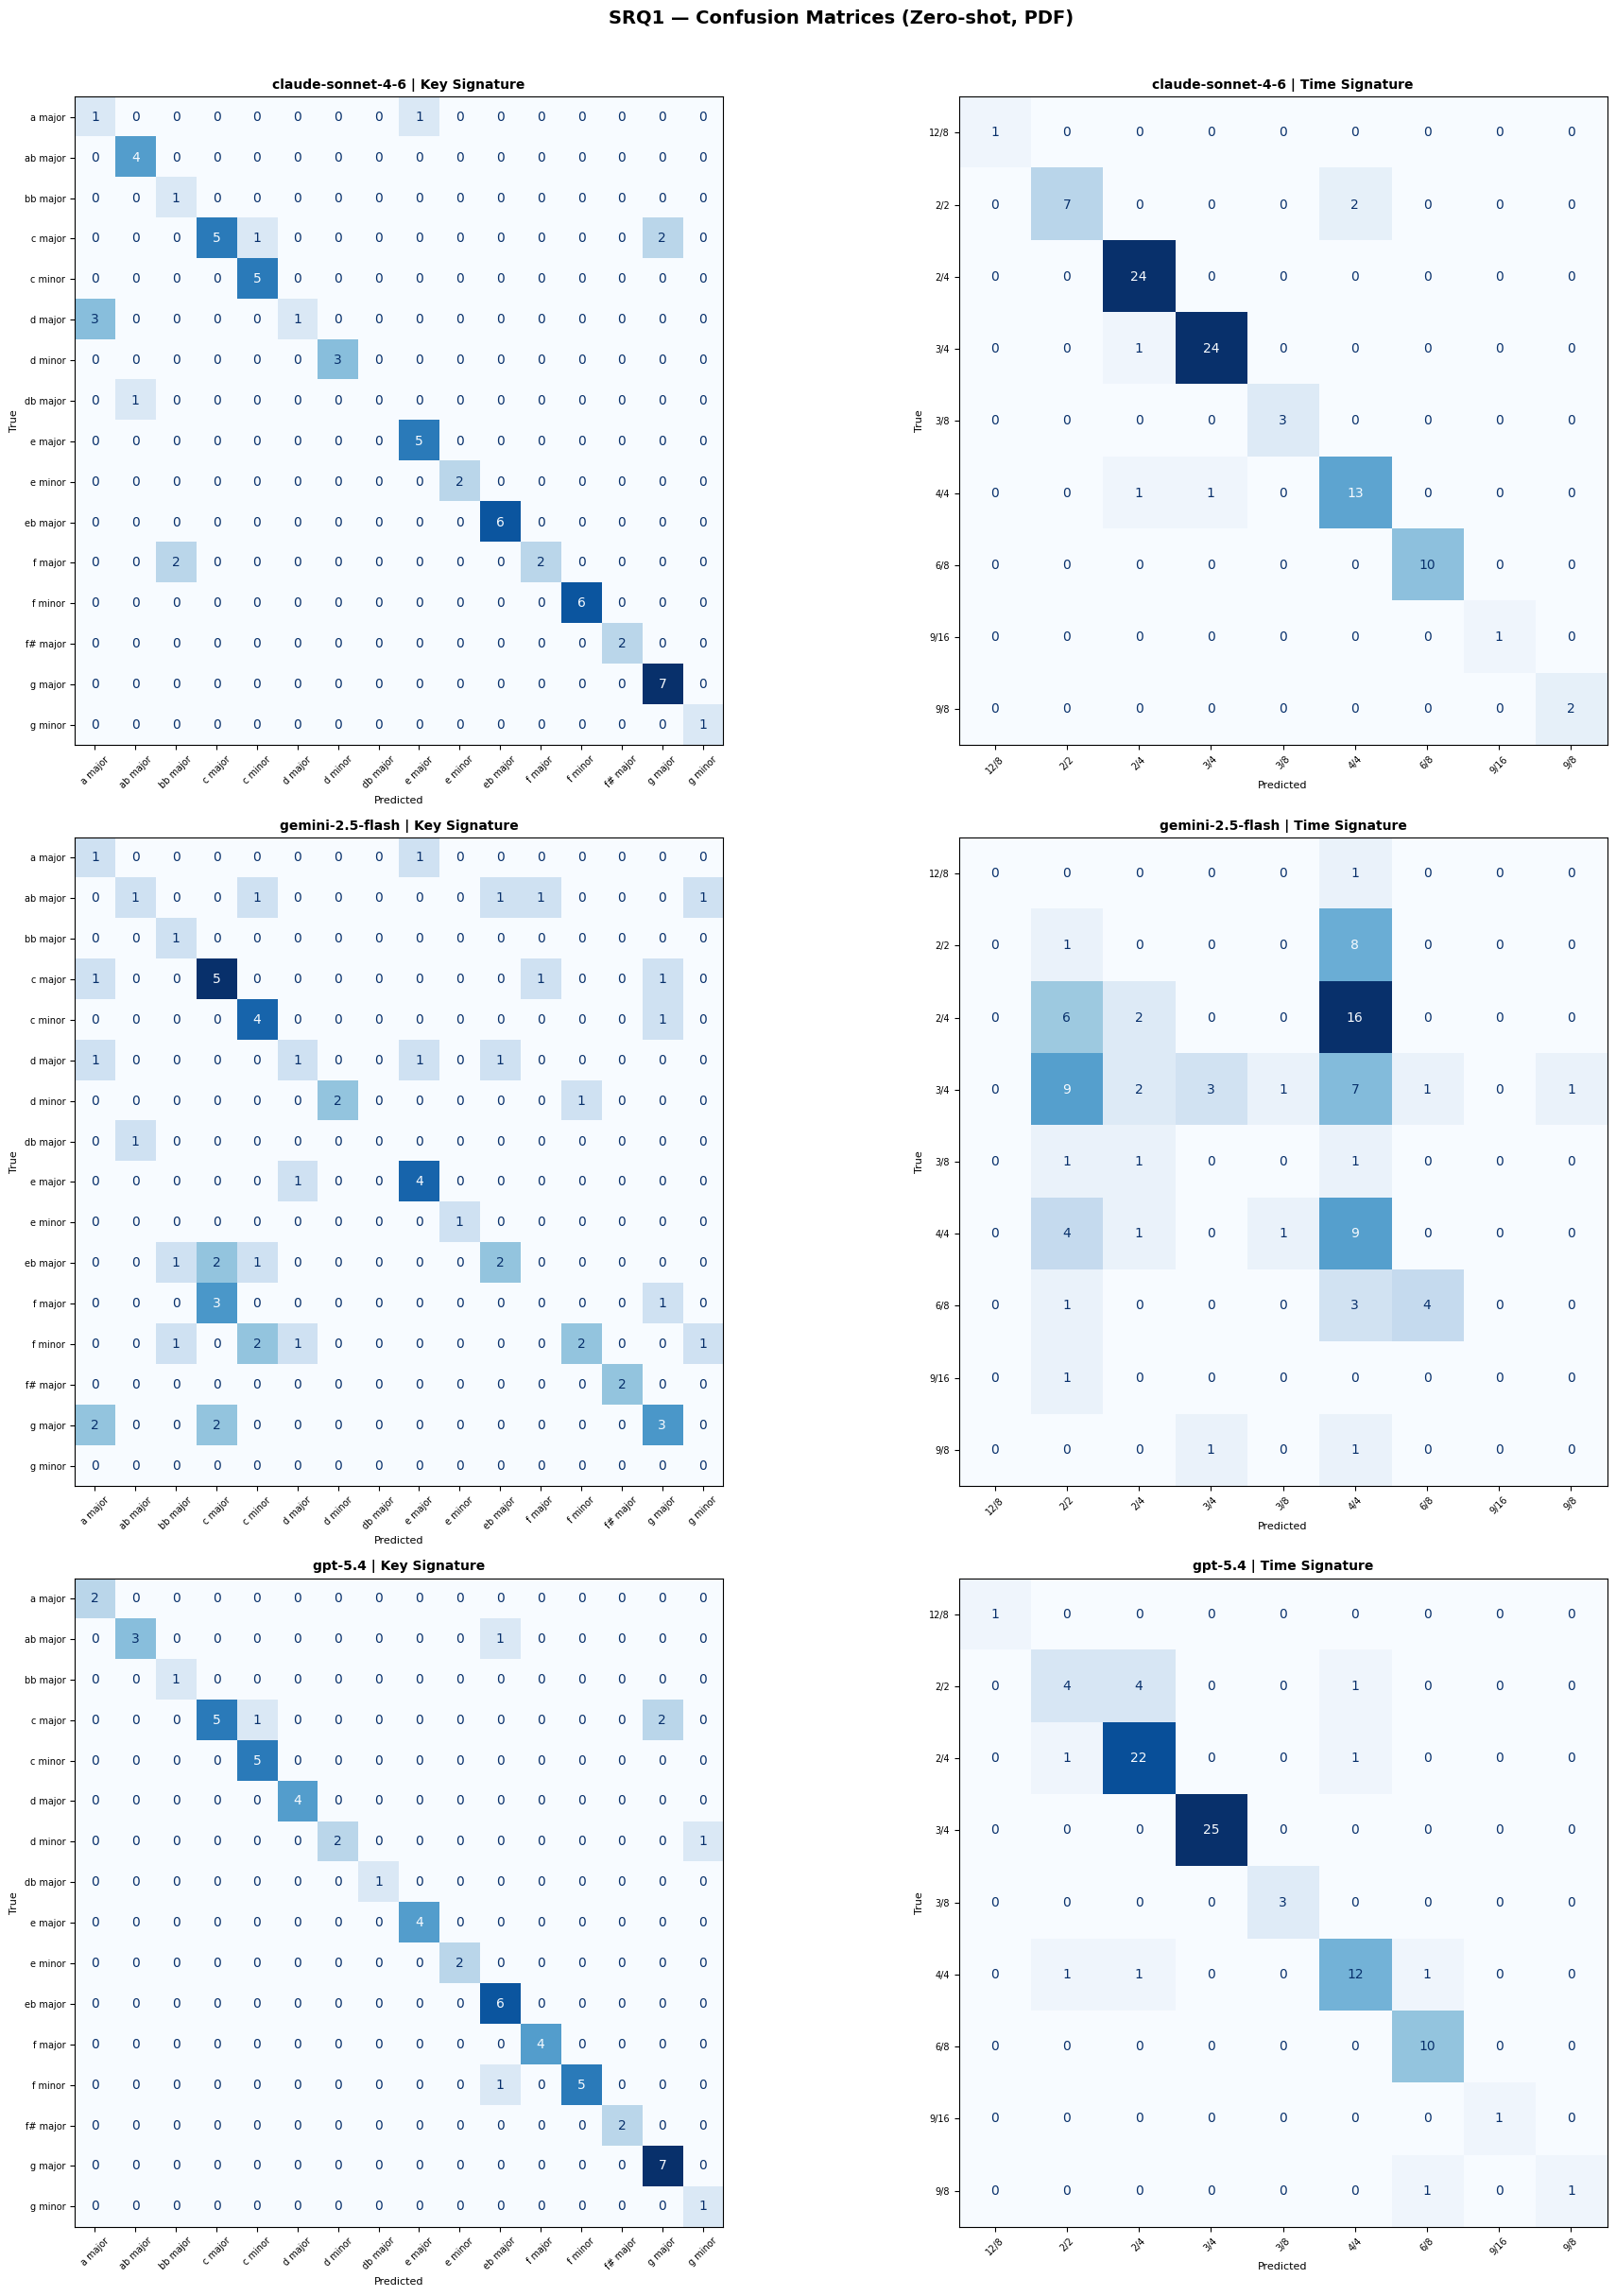

Saved to srq1_confusion_matrices.png


In [7]:
print("=" * 65)
print("SRQ1 — Confusion Matrices")
print("=" * 65)

fig, axes = plt.subplots(
    len(MODELS), len(TASKS),
    figsize=(20, 8 * len(MODELS))
)

fig.suptitle(
    "SRQ1 — Confusion Matrices (Zero-shot, PDF)",
    fontsize=14, fontweight="bold", y=1.01
)

for i, model in enumerate(MODELS):
    for j, task in enumerate(TASKS):
        df_sub = df1[
            (df1["model"] == model) &
            (df1["question_type"] == task)
        ].copy()

        df_sub["gt_norm"] = df_sub["ground_truth"].apply(
            lambda x: normalise_for_sklearn(x, task))
        df_sub["pred_norm"] = df_sub["parsed_answer"].fillna("unknown").apply(
            lambda x: normalise_for_sklearn(x, task))

        # Use union of true labels as display labels
        labels = sorted(df_sub["gt_norm"].unique())

        cm = confusion_matrix(
            df_sub["gt_norm"],
            df_sub["pred_norm"],
            labels=labels
        )

        ax = axes[i][j]
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=labels
        )
        disp.plot(ax=ax, colorbar=False,
                  xticks_rotation=45, cmap="Blues")
        ax.set_title(
            f"{model} | {task.replace('_', ' ').title()}",
            fontsize=10, fontweight="bold"
        )
        ax.set_xlabel("Predicted", fontsize=8)
        ax.set_ylabel("True", fontsize=8)
        ax.tick_params(axis="both", labelsize=7)

plt.tight_layout()
out_path = RESULTS_DIR / "srq1_confusion_matrices.png"
plt.savefig(out_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved to srq1_confusion_matrices.png")

---
## Cell 5 — SRQ1: Per-class accuracy

SRQ1 — Per-Class Accuracy (averaged across all 3 models)

  key_signature:
    db major             0.333  ██████████
    d major              0.500  ███████████████
    f major              0.500  ███████████████
    ab major             0.533  ████████████████
    f minor              0.619  ██████████████████
    c major              0.625  ██████████████████
    a major              0.667  ████████████████████
    g minor              0.667  ████████████████████
    d minor              0.778  ███████████████████████
    eb major             0.778  ███████████████████████
    g major              0.810  ████████████████████████
    e minor              0.833  █████████████████████████
    e major              0.867  ██████████████████████████
    c minor              0.933  ████████████████████████████
    bb major             1.000  ██████████████████████████████
    f# major             1.000  ██████████████████████████████

  time_signature:
    2/2                  0.444  █████

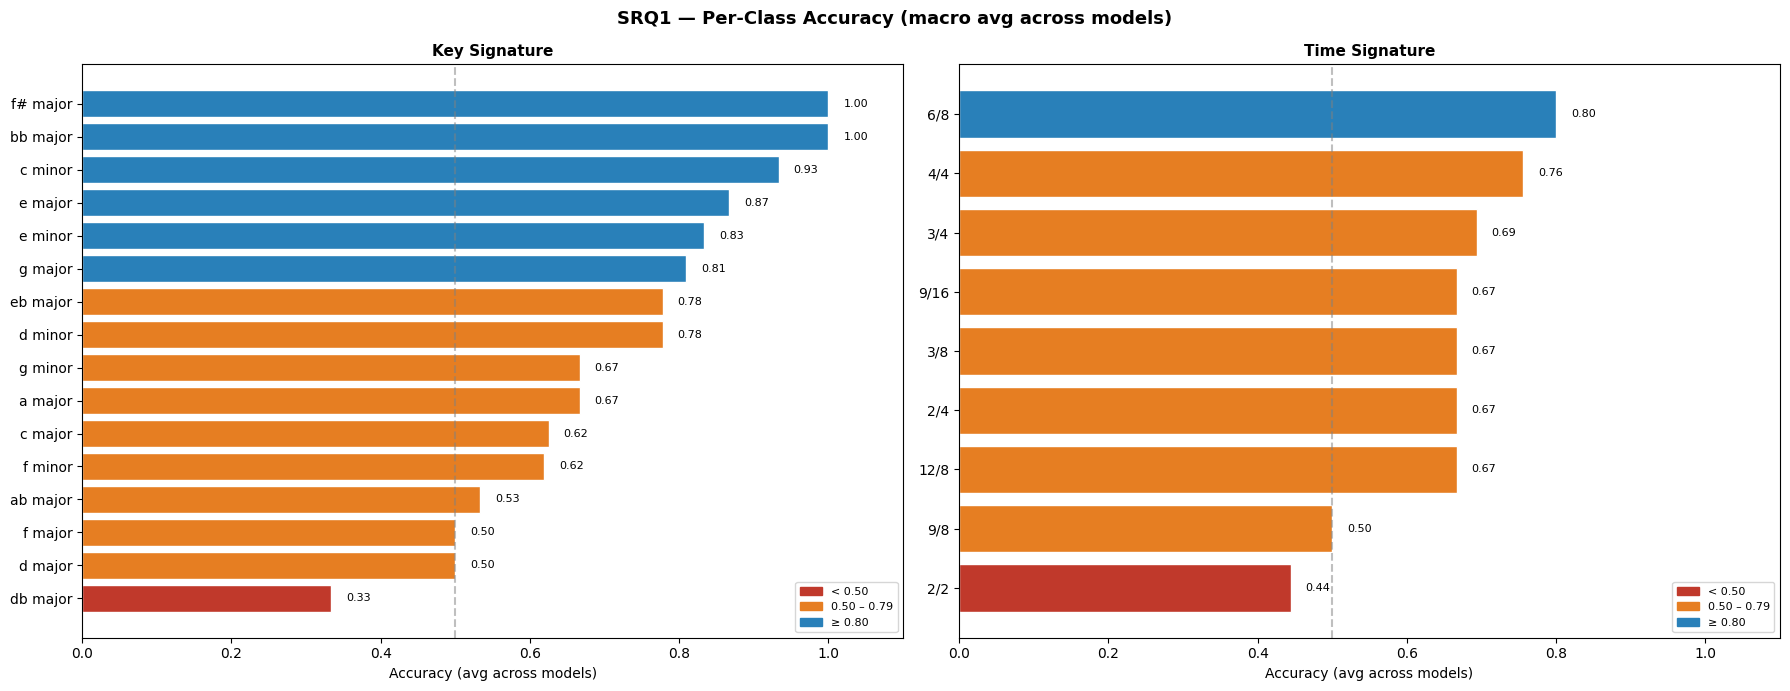


Saved to srq1_per_class_accuracy.png and .csv


In [8]:
print("=" * 65)
print("SRQ1 — Per-Class Accuracy (averaged across all 3 models)")
print("=" * 65)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    "SRQ1 — Per-Class Accuracy (macro avg across models)",
    fontsize=13, fontweight="bold"
)

per_class_records = []

for j, task in enumerate(TASKS):
    df_task = df1[df1["question_type"] == task].copy()

    df_task["gt_norm"] = df_task["ground_truth"].apply(
        lambda x: normalise_for_sklearn(x, task))

    # Average accuracy per class across all models
    class_acc = (
        df_task.groupby("gt_norm")["correct"]
        .mean()
        .sort_values()
    )

    # Store for CSV
    for cls, acc in class_acc.items():
        per_class_records.append({
            "srq": "srq1",
            "task": task,
            "class": cls,
            "accuracy_mean": round(acc, 4)
        })

    print(f"\n  {task}:")
    for cls, acc in class_acc.items():
        bar = "█" * int(acc * 30)
        print(f"    {cls:<20} {acc:.3f}  {bar}")

    # Plot
    ax = axes[j]
    colours = ["#c0392b" if a < 0.5 else "#2980b9" if a >= 0.8
               else "#e67e22" for a in class_acc.values]
    bars = ax.barh(class_acc.index, class_acc.values,
                   color=colours, edgecolor="white")
    ax.set_xlim(0, 1.1)
    ax.set_xlabel("Accuracy (avg across models)", fontsize=10)
    ax.set_title(task.replace("_", " ").title(), fontsize=11,
                 fontweight="bold")
    ax.axvline(0.5, color="grey", linestyle="--", alpha=0.5,
               label="0.5 threshold")

    # Value labels
    for bar, val in zip(bars, class_acc.values):
        ax.text(val + 0.02, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f}", va="center", fontsize=8)

    # Legend
    patches = [
        mpatches.Patch(color="#c0392b", label="< 0.50"),
        mpatches.Patch(color="#e67e22", label="0.50 – 0.79"),
        mpatches.Patch(color="#2980b9", label="≥ 0.80")
    ]
    ax.legend(handles=patches, fontsize=8, loc="lower right")

plt.tight_layout()
out_path = RESULTS_DIR / "srq1_per_class_accuracy.png"
plt.savefig(out_path, dpi=130, bbox_inches="tight")
plt.show()

pd.DataFrame(per_class_records).to_csv(
    RESULTS_DIR / "srq1_per_class_accuracy.csv", index=False)
print(f"\nSaved to srq1_per_class_accuracy.png and .csv")

---
## Cell 6 — SRQ1: Cross-model agreement (Definition A)
For each (movement, task): do all 3 models give the same answer?
Agreement is checked on **normalised** answers so surface differences
(e.g. 'F minor' vs 'f minor') don't count as disagreements.

In [9]:
print("=" * 65)
print("SRQ1 — Cross-Model Agreement (Definition A)")
print("All-or-nothing: consistent only if all 3 models agree exactly")
print("=" * 65)

agreement_records = []

for task in TASKS:
    df_task = df1[df1["question_type"] == task].copy()
    df_task["answer_norm"] = df_task["parsed_answer"].apply(
        lambda x: normalise_for_sklearn(x, task))

    movements = df_task["piece_id"].unique()

    for mid in movements:
        df_mov = df_task[df_task["piece_id"] == mid]

        model_answers = {}
        for model in MODELS:
            row = df_mov[df_mov["model"] == model]
            if row.empty:
                continue
            if row.iloc[0]["model_response"] == "ERROR":
                continue
            model_answers[model] = row.iloc[0]["answer_norm"]

        if len(model_answers) < 3:
            continue  # skip if any model missing

        answers   = list(model_answers.values())
        all_agree = len(set(answers)) == 1
        majority  = max(set(answers), key=answers.count)

        agreement_records.append({
            "piece_id":      mid,
            "question_type": task,
            "claude_answer": model_answers.get("claude-sonnet-4-6", "missing"),
            "gemini_answer": model_answers.get("gemini-2.5-flash",  "missing"),
            "gpt_answer":    model_answers.get("gpt-5.4",           "missing"),
            "majority":      majority,
            "all_agree":     all_agree
        })

agreement_df = pd.DataFrame(agreement_records)

# ── PRINT SUMMARY ─────────────────────────────────────────────────────────────

print("\nPer-task agreement rate (all 3 models give same answer):")
for task in TASKS:
    sub = agreement_df[agreement_df["question_type"] == task]
    n   = len(sub)
    n_a = sub["all_agree"].sum()
    print(f"  {task:<20}: {n_a}/{n} = {n_a/n:.1%}")

total   = len(agreement_df)
n_agree = agreement_df["all_agree"].sum()
print(f"\nCombined (both tasks): {n_agree}/{total} = {n_agree/total:.1%}")
print("  (for reference only — tasks differ in difficulty)")

print("\nPer-model majority match rate:")
for model, col in [
    ("claude-sonnet-4-6", "claude_answer"),
    ("gemini-2.5-flash",  "gemini_answer"),
    ("gpt-5.4",           "gpt_answer")
]:
    n_match = agreement_df.apply(
        lambda row: row[col] == row["majority"], axis=1
    ).sum()
    print(f"  {model:<25}: {n_match}/{total} = {n_match/total:.1%}")

# ── DISAGREEMENT CASES ────────────────────────────────────────────────────────

disagreements = agreement_df[~agreement_df["all_agree"]]
print(f"\nDisagreement cases: {len(disagreements)} / {total}")
if len(disagreements) > 0:
    print("\nFirst 15 disagreements:")
    print(
        disagreements[
            ["piece_id", "question_type",
             "claude_answer", "gemini_answer", "gpt_answer"]
        ].head(15).to_string(index=False)
    )

# ── SAVE ─────────────────────────────────────────────────────────────────────
agreement_df.to_csv(RESULTS_DIR / "srq1_agreement.csv", index=False)
print(f"\nFull agreement table saved to srq1_agreement.csv")

SRQ1 — Cross-Model Agreement (Definition A)
All-or-nothing: consistent only if all 3 models agree exactly

Per-task agreement rate (all 3 models give same answer):
  key_signature       : 23/63 = 36.5%
  time_signature      : 17/90 = 18.9%

Combined (both tasks): 40/153 = 26.1%
  (for reference only — tasks differ in difficulty)

Per-model majority match rate:
  claude-sonnet-4-6        : 137/153 = 89.5%
  gemini-2.5-flash         : 54/153 = 35.3%
  gpt-5.4                  : 142/153 = 92.8%

Disagreement cases: 113 / 153

First 15 disagreements:
piece_id question_type claude_answer gemini_answer gpt_answer
    01-1 key_signature       f minor       c minor    f minor
    01-2 key_signature       f major       c major    f major
    01-3 key_signature       f minor      bb major   eb major
    01-4 key_signature       f minor       c minor    f minor
    02-1 key_signature       e major       a major    a major
    02-2 key_signature       d major      eb major    d major
    02-3 key_

---
# SRQ3 Analyses
## Cell 7 — SRQ3: Accuracy summary table

In [10]:
print("=" * 75)
print("SRQ3 — Accuracy Summary (Role prompt, PDF vs PNG)")
print("=" * 75)
print(f"{'model':<25} {'format':<6} {'task':<20} {'n':>4} {'errors':>6} "
      f"{'accuracy':>9} {'precision':>10} {'recall':>7} {'f1':>6}")
print("-" * 95)

srq3_summary = []

for model in MODELS:
    for fmt in ["pdf", "png"]:
        for task in TASKS:
            sub = df3[
                (df3["model"] == model) &
                (df3["input_type"] == fmt) &
                (df3["question_type"] == task)
            ]
            m = compute_metrics(sub, task)
            print(f"{model:<25} {fmt:<6} {task:<20} {m['n']:>4} "
                  f"{m['n_errors']:>6} {m['accuracy']:>9.3f} "
                  f"{m['precision']:>10.3f} {m['recall']:>7.3f} "
                  f"{m['f1']:>6.3f}")
            srq3_summary.append({
                "model": model, "format": fmt, "task": task, **m})

print("\nAll metrics use macro averaging.")

srq3_summary_df = pd.DataFrame(srq3_summary)
srq3_summary_df.to_csv(RESULTS_DIR / "srq3_summary.csv", index=False)
print(f"Saved to srq3_summary.csv")

SRQ3 — Accuracy Summary (Role prompt, PDF vs PNG)
model                     format task                    n errors  accuracy  precision  recall     f1
-----------------------------------------------------------------------------------------------
claude-sonnet-4-6         pdf    key_signature          63      0     0.794      0.722   0.693  0.681
claude-sonnet-4-6         pdf    time_signature         90      0     0.933      0.875   0.852  0.859
claude-sonnet-4-6         png    key_signature          63      0     0.889      0.785   0.767  0.750
claude-sonnet-4-6         png    time_signature         90      0     0.867      0.835   0.770  0.779
gemini-2.5-flash          pdf    key_signature          63      0     0.413      0.375   0.347  0.300
gemini-2.5-flash          pdf    time_signature         90      0     0.222      0.225   0.137  0.110
gemini-2.5-flash          png    key_signature          63      0     0.333      0.185   0.205  0.172
gemini-2.5-flash          png    time_

---
## Cell 8 — SRQ3: McNemar's test (PDF vs PNG)
**Why McNemar's?** The same movements appear in both PDF and PNG conditions,
so the data is paired. McNemar's is the standard test for paired binary
outcomes (correct / incorrect). It tests whether the disagreements between
the two formats are symmetric — i.e. does one format produce significantly
more correct answers than the other?

H0: no significant difference in accuracy between PDF and PNG.

In [11]:
print("=" * 65)
print("SRQ3 — McNemar's Test: PDF vs PNG")
print("H0: no significant difference in accuracy between formats")
print("=" * 65)

mcnemar_records = []

for model in MODELS:
    for task in TASKS:
        df_pdf = df3[
            (df3["model"] == model) &
            (df3["question_type"] == task) &
            (df3["input_type"] == "pdf")
        ].set_index("piece_id")["correct"]

        df_png = df3[
            (df3["model"] == model) &
            (df3["question_type"] == task) &
            (df3["input_type"] == "png")
        ].set_index("piece_id")["correct"]

        # Align on shared movements only
        shared      = df_pdf.index.intersection(df_png.index)
        pdf_correct = df_pdf.loc[shared].astype(bool)
        png_correct = df_png.loc[shared].astype(bool)

        # 2x2 contingency table
        both_correct = (pdf_correct & png_correct).sum()
        pdf_only     = (pdf_correct & ~png_correct).sum()  # PDF right PNG wrong
        png_only     = (~pdf_correct & png_correct).sum()  # PNG right PDF wrong
        both_wrong   = (~pdf_correct & ~png_correct).sum()

        table = [[both_correct, pdf_only],
                 [png_only,     both_wrong]]

        # McNemar test — exact=True recommended when off-diagonal counts are small
        try:
            result  = mcnemar(table, exact=True, correction=False)
            p_value = result.pvalue
        except Exception:
            p_value = float("nan")

        sig = ("***" if p_value < 0.001 else
               "**"  if p_value < 0.01  else
               "*"   if p_value < 0.05  else "ns")

        acc_pdf = pdf_correct.mean()
        acc_png = png_correct.mean()
        delta   = acc_png - acc_pdf  # positive = PNG better

        print(f"\n  {model} | {task}")
        print(f"    n (shared movements):  {len(shared)}")
        print(f"    PDF acc = {acc_pdf:.3f}   PNG acc = {acc_png:.3f}   "
              f"Δ = {delta:+.3f} ({'PNG better' if delta > 0 else 'PDF better'})")
        print(f"    Contingency table:")
        print(f"      Both correct:  {both_correct}")
        print(f"      PDF only:      {pdf_only}")
        print(f"      PNG only:      {png_only}")
        print(f"      Both wrong:    {both_wrong}")
        print(f"    McNemar p = {p_value:.4f}  {sig}")

        mcnemar_records.append({
            "model":        model,
            "task":         task,
            "n_shared":     int(len(shared)),
            "acc_pdf":      round(acc_pdf, 4),
            "acc_png":      round(acc_png, 4),
            "delta":        round(delta, 4),
            "both_correct": int(both_correct),
            "pdf_only":     int(pdf_only),
            "png_only":     int(png_only),
            "both_wrong":   int(both_wrong),
            "p_value":      round(p_value, 4),
            "significant":  sig
        })

print("\n" + "-" * 65)
print("Significance: *** p<.001  ** p<.01  * p<.05  ns = not significant")

mcnemar_df = pd.DataFrame(mcnemar_records)
mcnemar_df.to_csv(RESULTS_DIR / "srq3_mcnemar.csv", index=False)
print(f"Saved to srq3_mcnemar.csv")

SRQ3 — McNemar's Test: PDF vs PNG
H0: no significant difference in accuracy between formats

  claude-sonnet-4-6 | key_signature
    n (shared movements):  63
    PDF acc = 0.794   PNG acc = 0.889   Δ = +0.095 (PNG better)
    Contingency table:
      Both correct:  49
      PDF only:      1
      PNG only:      7
      Both wrong:    6
    McNemar p = 0.0703  ns

  claude-sonnet-4-6 | time_signature
    n (shared movements):  90
    PDF acc = 0.933   PNG acc = 0.867   Δ = -0.067 (PDF better)
    Contingency table:
      Both correct:  76
      PDF only:      8
      PNG only:      2
      Both wrong:    4
    McNemar p = 0.1094  ns

  gemini-2.5-flash | key_signature
    n (shared movements):  63
    PDF acc = 0.413   PNG acc = 0.333   Δ = -0.079 (PDF better)
    Contingency table:
      Both correct:  12
      PDF only:      14
      PNG only:      9
      Both wrong:    28
    McNemar p = 0.4049  ns

  gemini-2.5-flash | time_signature
    n (shared movements):  90
    PDF acc = 0.2

---
## Cell 9 — SRQ3: Format effect direction
When PDF and PNG produced different answers for the same movement,
which format was correct? Breaks down into three cases:
- **PDF better**: PDF correct, PNG wrong
- **PNG better**: PNG correct, PDF wrong
- **Both wrong**: both wrong but gave different answers

In [12]:
print("=" * 65)
print("SRQ3 — Format Effect Direction")
print("When PDF and PNG disagreed, which format was correct?")
print("=" * 65)

direction_records = []

for model in MODELS:
    print(f"\n  {model}")
    for task in TASKS:
        df_pdf = df3[
            (df3["model"] == model) &
            (df3["question_type"] == task) &
            (df3["input_type"] == "pdf")
        ].set_index("piece_id")

        df_png = df3[
            (df3["model"] == model) &
            (df3["question_type"] == task) &
            (df3["input_type"] == "png")
        ].set_index("piece_id")

        shared  = df_pdf.index.intersection(df_png.index)
        pdf_c   = df_pdf.loc[shared, "correct"].astype(bool)
        png_c   = df_png.loc[shared, "correct"].astype(bool)

        # Only look at cases where answers disagreed
        pdf_ans = df_pdf.loc[shared, "parsed_answer"].fillna("")
        png_ans = df_png.loc[shared, "parsed_answer"].fillna("")

        # Normalise before comparing answers
        pdf_norm = pdf_ans.apply(lambda x: normalise_for_sklearn(x, task))
        png_norm = png_ans.apply(lambda x: normalise_for_sklearn(x, task))
        answer_differs = pdf_norm != png_norm

        pdf_better  = (pdf_c & ~png_c).sum()
        png_better  = (~pdf_c & png_c).sum()
        both_differ_wrong = (answer_differs & ~pdf_c & ~png_c).sum()
        n_disagree  = answer_differs.sum()

        print(f"    {task:<20}: {n_disagree} disagreements  "
              f"→  PDF better={pdf_better}, "
              f"PNG better={png_better}, "
              f"both wrong={both_differ_wrong}")

        direction_records.append({
            "model":            model,
            "task":             task,
            "n_disagreements":  int(n_disagree),
            "pdf_better":       int(pdf_better),
            "png_better":       int(png_better),
            "both_wrong":       int(both_differ_wrong)
        })

direction_df = pd.DataFrame(direction_records)
direction_df.to_csv(RESULTS_DIR / "srq3_format_direction.csv", index=False)
print(f"\nSaved to srq3_format_direction.csv")

SRQ3 — Format Effect Direction
When PDF and PNG disagreed, which format was correct?

  claude-sonnet-4-6
    key_signature       : 8 disagreements  →  PDF better=1, PNG better=7, both wrong=0
    time_signature      : 11 disagreements  →  PDF better=8, PNG better=2, both wrong=1

  gemini-2.5-flash
    key_signature       : 44 disagreements  →  PDF better=14, PNG better=9, both wrong=21
    time_signature      : 62 disagreements  →  PDF better=10, PNG better=10, both wrong=42

  gpt-5.4
    key_signature       : 17 disagreements  →  PDF better=13, PNG better=1, both wrong=3
    time_signature      : 7 disagreements  →  PDF better=0, PNG better=6, both wrong=1

Saved to srq3_format_direction.csv


---
## Cell 10 — SRQ3: Confusion matrices (per model, per task, per format)

SRQ3 — Confusion Matrices (PDF vs PNG, key signature only)


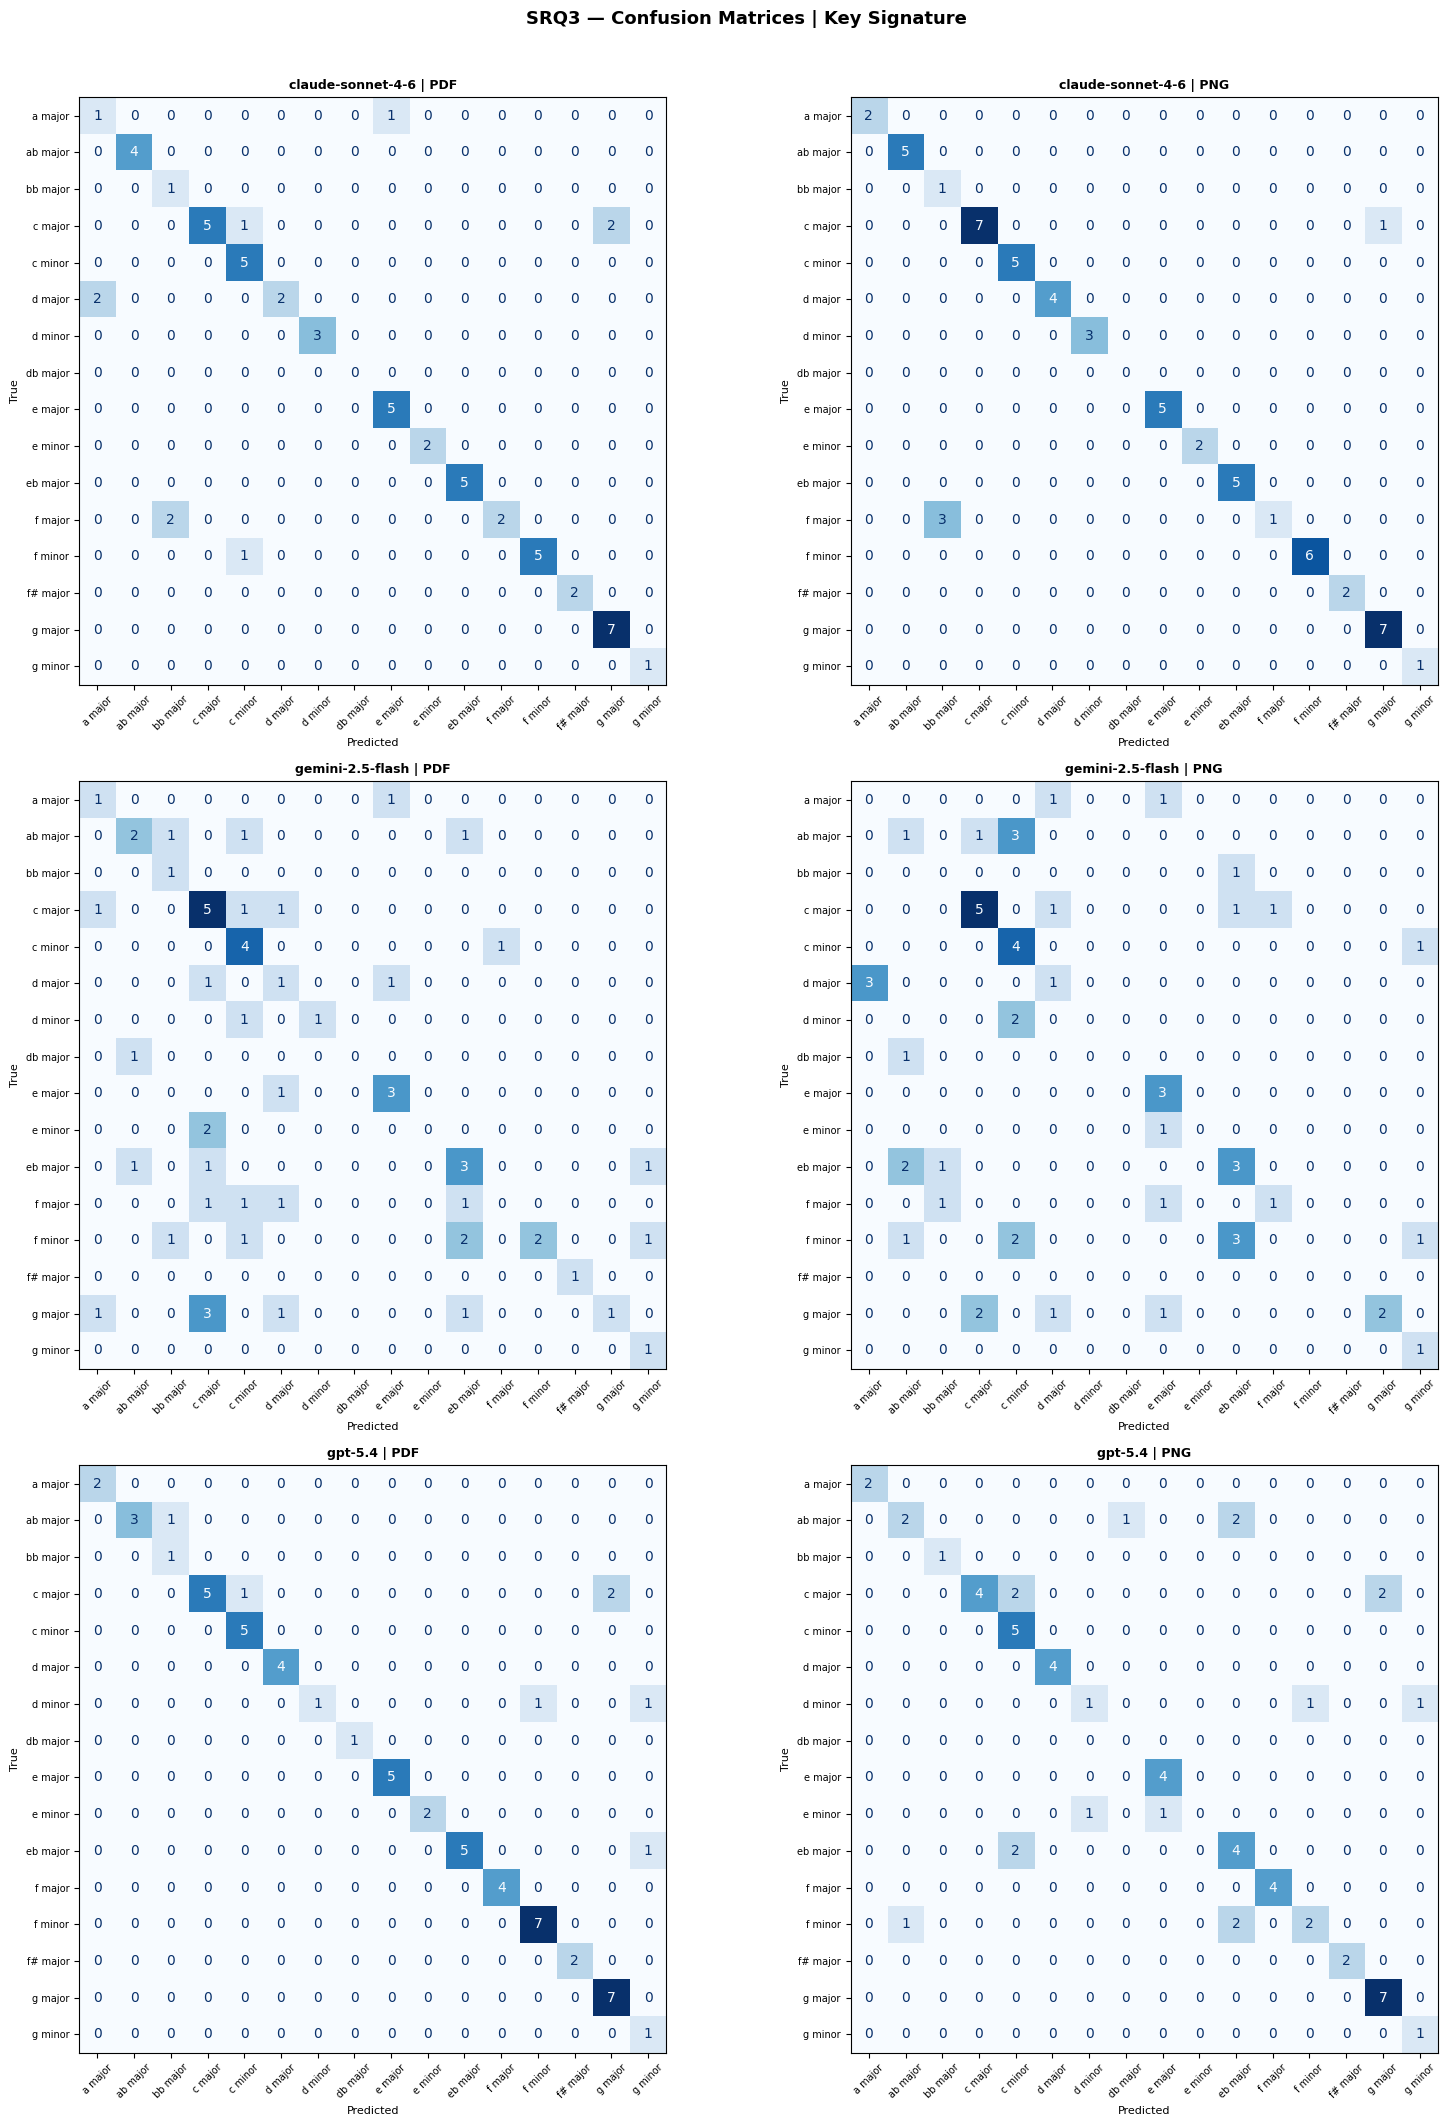

Saved to srq3_confusion_key_signature.png


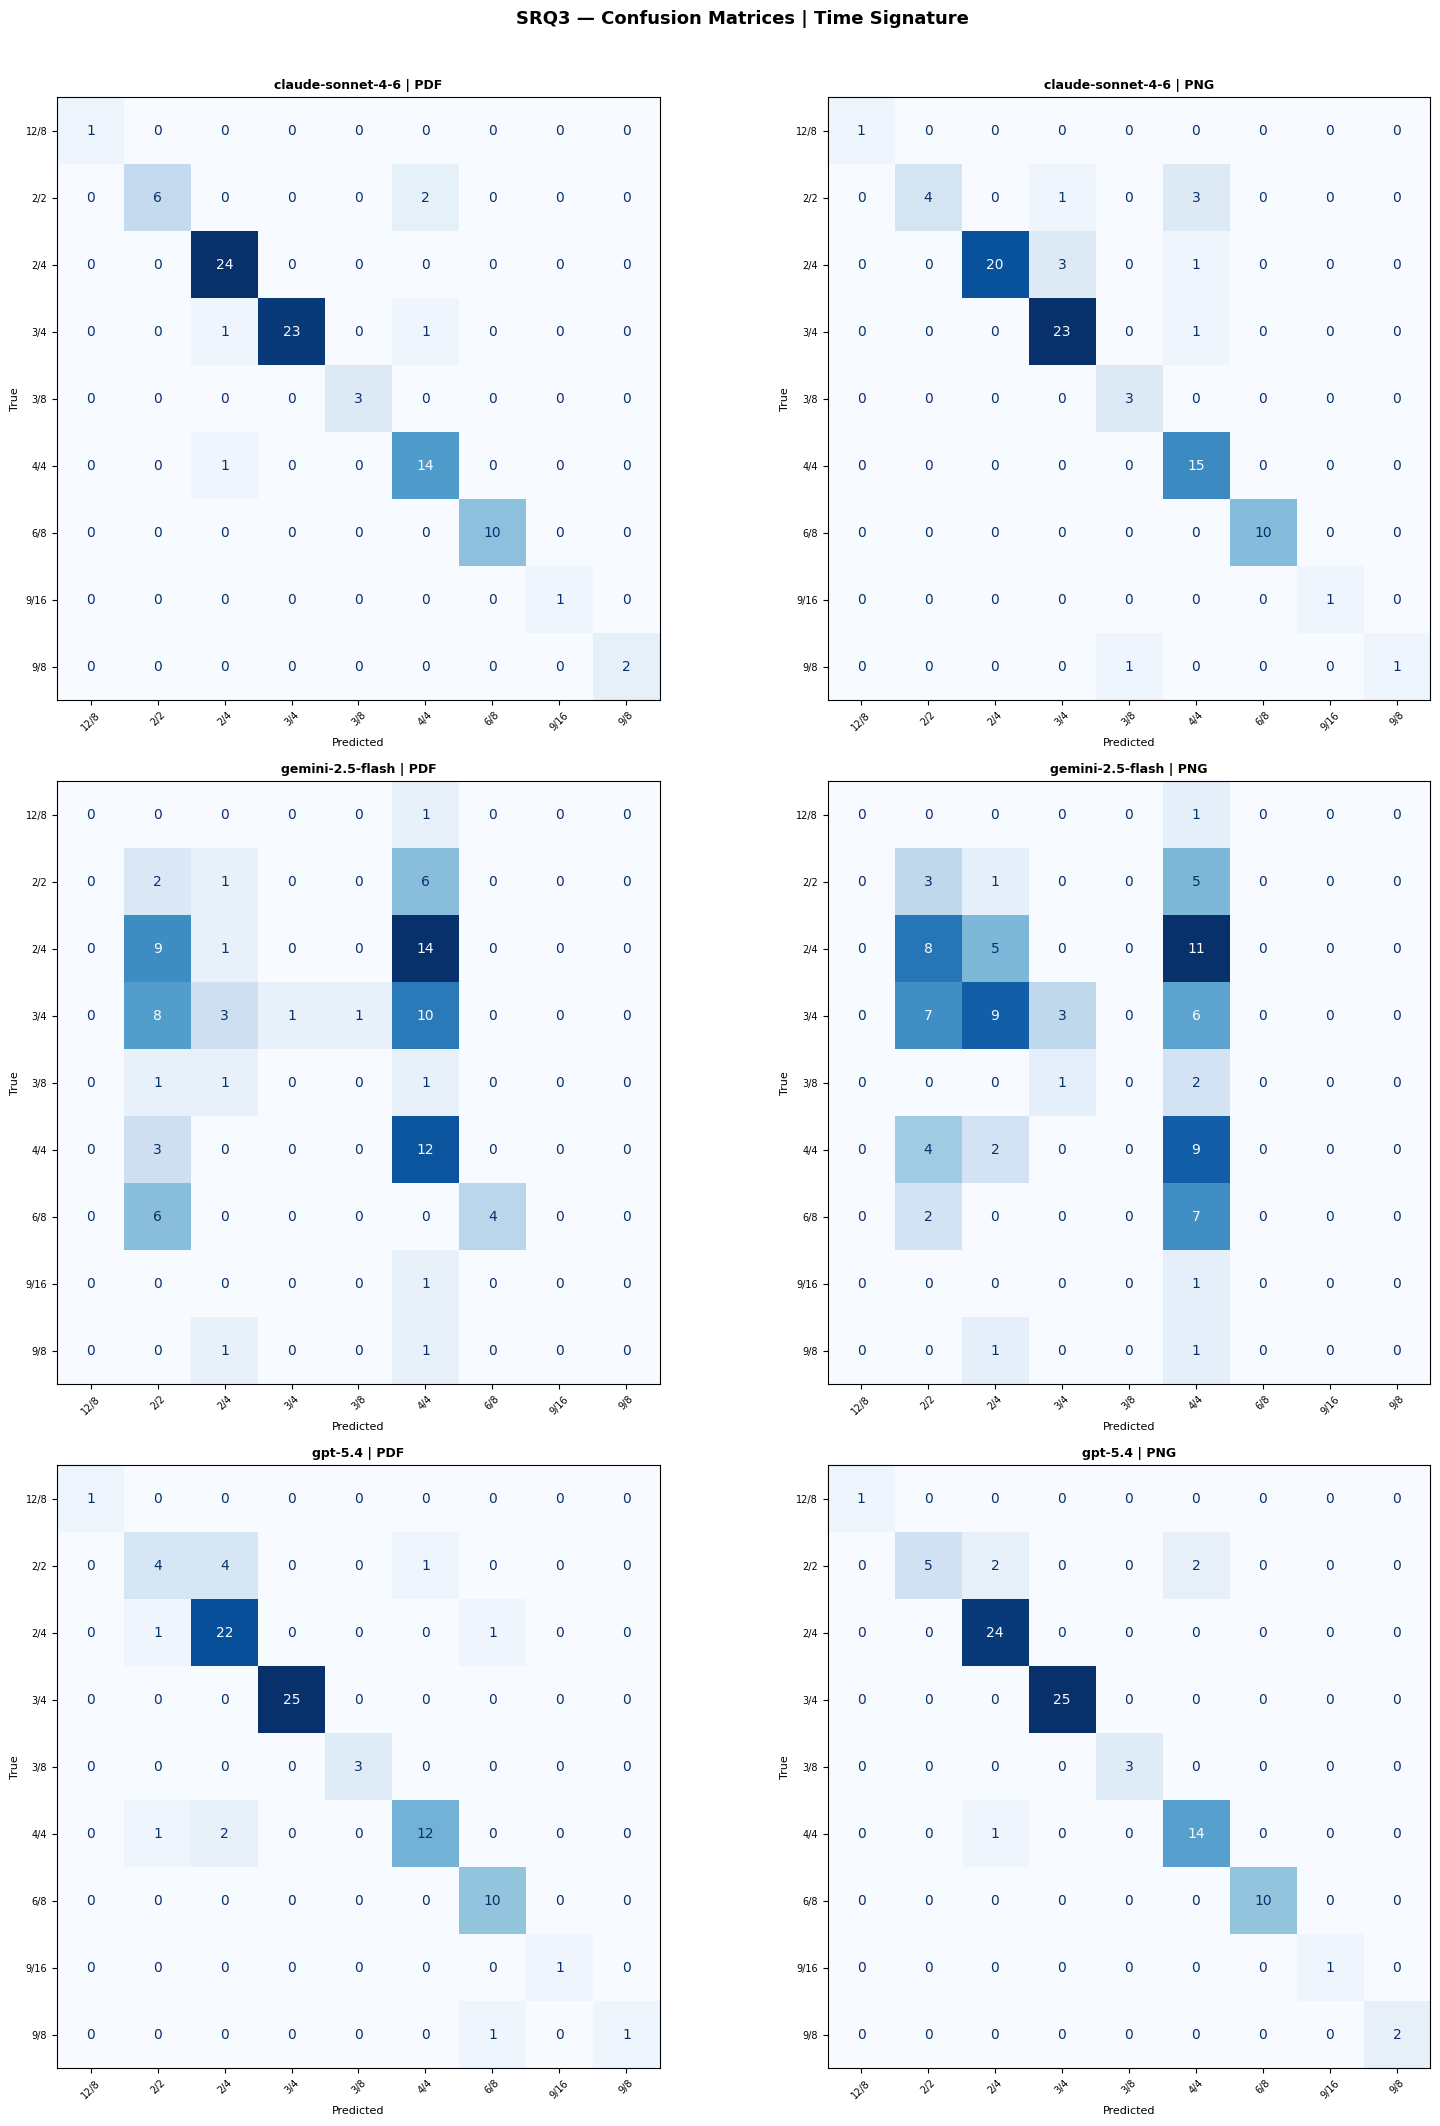

Saved to srq3_confusion_time_signature.png


In [13]:
print("=" * 65)
print("SRQ3 — Confusion Matrices (PDF vs PNG, key signature only)")
print("=" * 65)

FORMATS = ["pdf", "png"]

# One figure per task to keep it readable
for task in TASKS:
    fig, axes = plt.subplots(
        len(MODELS), len(FORMATS),
        figsize=(16, 7 * len(MODELS))
    )
    fig.suptitle(
        f"SRQ3 — Confusion Matrices | {task.replace('_',' ').title()}",
        fontsize=13, fontweight="bold", y=1.01
    )

    # Determine a shared label set across all model/format combos for this task
    all_gt = df3[df3["question_type"] == task]["ground_truth"].apply(
        lambda x: normalise_for_sklearn(x, task)).unique()
    labels = sorted(all_gt)

    for i, model in enumerate(MODELS):
        for j, fmt in enumerate(FORMATS):
            df_sub = df3[
                (df3["model"] == model) &
                (df3["question_type"] == task) &
                (df3["input_type"] == fmt)
            ].copy()

            df_sub["gt_norm"] = df_sub["ground_truth"].apply(
                lambda x: normalise_for_sklearn(x, task))
            df_sub["pred_norm"] = df_sub["parsed_answer"].fillna("unknown").apply(
                lambda x: normalise_for_sklearn(x, task))

            cm = confusion_matrix(
                df_sub["gt_norm"],
                df_sub["pred_norm"],
                labels=labels
            )

            ax = axes[i][j]
            disp = ConfusionMatrixDisplay(
                confusion_matrix=cm,
                display_labels=labels
            )
            disp.plot(ax=ax, colorbar=False,
                      xticks_rotation=45, cmap="Blues")
            ax.set_title(
                f"{model} | {fmt.upper()}",
                fontsize=9, fontweight="bold"
            )
            ax.set_xlabel("Predicted", fontsize=8)
            ax.set_ylabel("True", fontsize=8)
            ax.tick_params(axis="both", labelsize=7)

    plt.tight_layout()
    out_path = RESULTS_DIR / f"srq3_confusion_{task}.png"
    plt.savefig(out_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved to srq3_confusion_{task}.png")

---
## Cell 11 — SRQ3: Per-class accuracy delta (PDF vs PNG)
For each class, how much does accuracy change between PDF and PNG?
Positive delta = PNG is better for that class.
Negative delta = PDF is better for that class.

SRQ3 — Per-Class Accuracy Delta (PNG acc - PDF acc)
Averaged across all 3 models

  key_signature:
  class                   pdf_acc  png_acc    delta
  bb major                  1.000    0.667   -0.333  PDF↑
  db major                  0.333    0.000   -0.333  PDF↑
  e minor                   0.667    0.333   -0.333  PDF↑
  f minor                   0.667    0.381   -0.286  PDF↑
  f# major                  0.833    0.667   -0.167  PDF↑
  d minor                   0.556    0.444   -0.111  PDF↑
  ab major                  0.600    0.533   -0.067  PDF↑
  e major                   0.867    0.800   -0.067  PDF↑
  eb major                  0.722    0.667   -0.056  PDF↑
  a major                   0.667    0.667   +0.000  ~equal
  c minor                   0.933    0.933   +0.000  ~equal
  f major                   0.500    0.500   +0.000  ~equal
  g minor                   1.000    1.000   +0.000  ~equal
  c major                   0.625    0.667   +0.042  ~equal
  g major                  

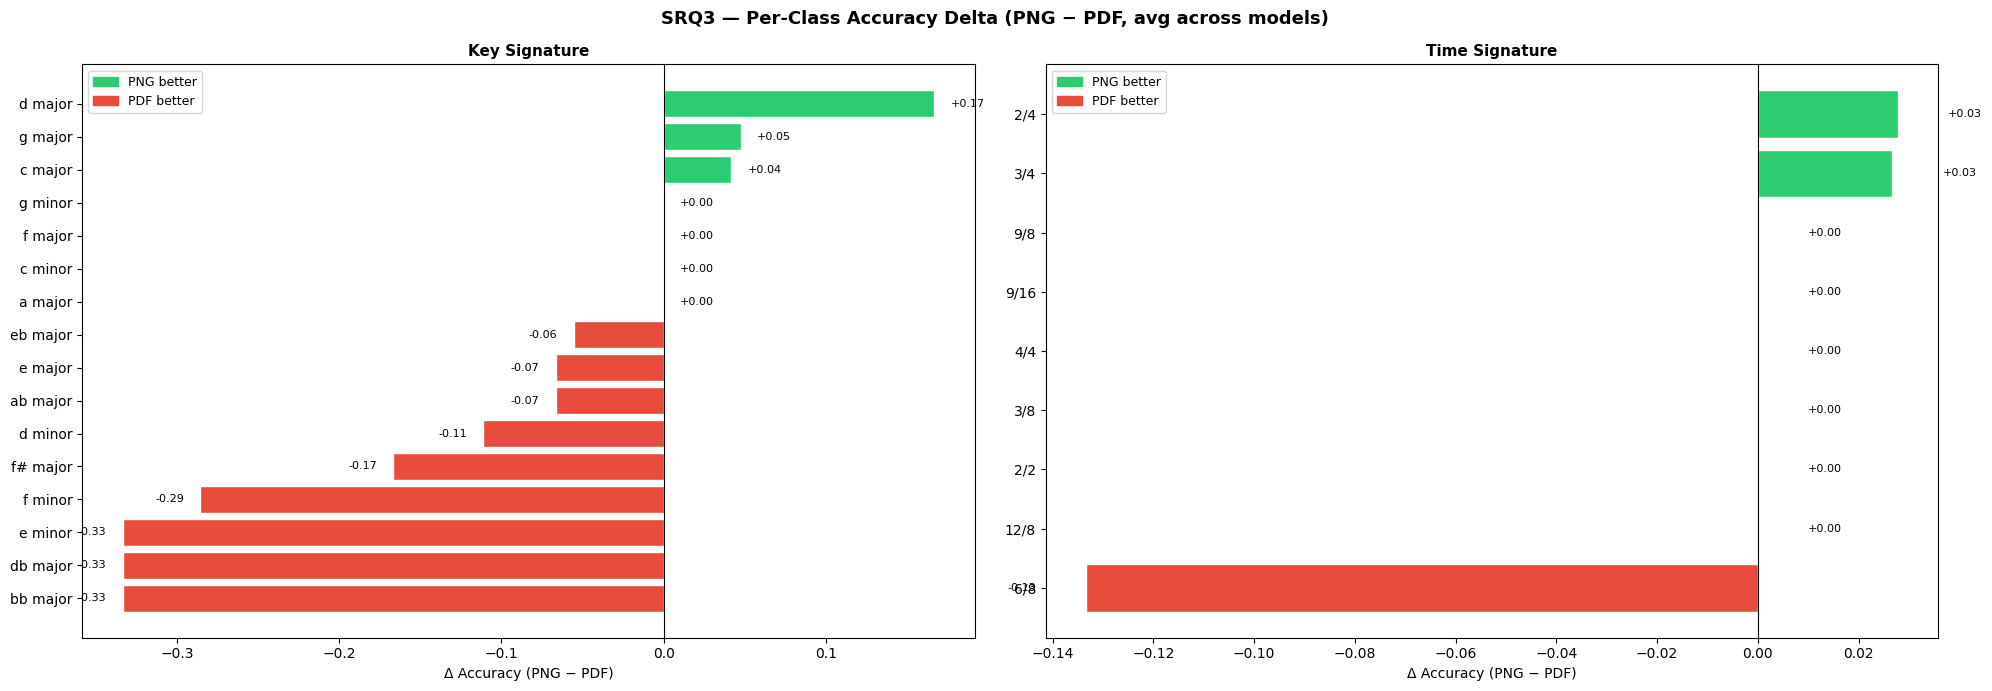


Saved to srq3_per_class_delta.png and .csv


In [14]:
print("=" * 65)
print("SRQ3 — Per-Class Accuracy Delta (PNG acc - PDF acc)")
print("Averaged across all 3 models")
print("=" * 65)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle(
    "SRQ3 — Per-Class Accuracy Delta (PNG − PDF, avg across models)",
    fontsize=13, fontweight="bold"
)

delta_records = []

for j, task in enumerate(TASKS):
    df_task = df3[df3["question_type"] == task].copy()
    df_task["gt_norm"] = df_task["ground_truth"].apply(
        lambda x: normalise_for_sklearn(x, task))

    # Average accuracy per (class, format) across models
    class_fmt_acc = (
        df_task.groupby(["gt_norm", "input_type"])["correct"]
        .mean()
        .unstack("input_type")
    )

    # Delta: PNG - PDF
    class_fmt_acc["delta"] = (
        class_fmt_acc.get("png", pd.Series(dtype=float)) -
        class_fmt_acc.get("pdf", pd.Series(dtype=float))
    )
    class_fmt_acc = class_fmt_acc.sort_values("delta")

    print(f"\n  {task}:")
    print(f"  {'class':<22} {'pdf_acc':>8} {'png_acc':>8} {'delta':>8}")
    for cls, row in class_fmt_acc.iterrows():
        delta_records.append({
            "task": task, "class": cls,
            "pdf_acc": round(row.get("pdf", float("nan")), 4),
            "png_acc": round(row.get("png", float("nan")), 4),
            "delta":   round(row["delta"], 4)
        })
        direction = "PNG↑" if row["delta"] > 0.05 else "PDF↑" if row["delta"] < -0.05 else "~equal"
        print(f"  {cls:<22} {row.get('pdf', float('nan')):>8.3f} "
              f"{row.get('png', float('nan')):>8.3f} "
              f"{row['delta']:>+8.3f}  {direction}")

    # Plot
    ax = axes[j]
    deltas  = class_fmt_acc["delta"]
    colours = ["#2ecc71" if d > 0 else "#e74c3c" for d in deltas]
    bars    = ax.barh(deltas.index, deltas.values,
                      color=colours, edgecolor="white")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Δ Accuracy (PNG − PDF)", fontsize=10)
    ax.set_title(task.replace("_", " ").title(), fontsize=11,
                 fontweight="bold")

    # Value labels
    for bar, val in zip(bars, deltas.values):
        xpos = val + 0.01 if val >= 0 else val - 0.01
        ha   = "left" if val >= 0 else "right"
        ax.text(xpos, bar.get_y() + bar.get_height() / 2,
                f"{val:+.2f}", va="center", ha=ha, fontsize=8)

    patches = [
        mpatches.Patch(color="#2ecc71", label="PNG better"),
        mpatches.Patch(color="#e74c3c", label="PDF better")
    ]
    ax.legend(handles=patches, fontsize=9)

plt.tight_layout()
out_path = RESULTS_DIR / "srq3_per_class_delta.png"
plt.savefig(out_path, dpi=130, bbox_inches="tight")
plt.show()

pd.DataFrame(delta_records).to_csv(
    RESULTS_DIR / "srq3_per_class_delta.csv", index=False)
print(f"\nSaved to srq3_per_class_delta.png and .csv")

---
## Cell 12 — SRQ3: Cross-format consistency (Definition B)
For each (movement, model, task): does the model give the same answer
on PDF as on PNG, **regardless of whether that answer is correct**?

High consistency = format change does not affect the model's output.
Low consistency = format change causes the model to give different answers.

SRQ3 — Cross-Format Consistency (Definition B)
Same answer on PDF and PNG? (regardless of correctness)

  claude-sonnet-4-6
    key_signature       : 55/63 = 87.3%
    time_signature      : 79/90 = 87.8%

  gemini-2.5-flash
    key_signature       : 19/63 = 30.2%
    time_signature      : 28/90 = 31.1%

  gpt-5.4
    key_signature       : 46/63 = 73.0%
    time_signature      : 83/90 = 92.2%

  Overall consistency per model (avg across tasks):
    claude-sonnet-4-6        : 87.5%
    gemini-2.5-flash         : 30.6%
    gpt-5.4                  : 82.6%


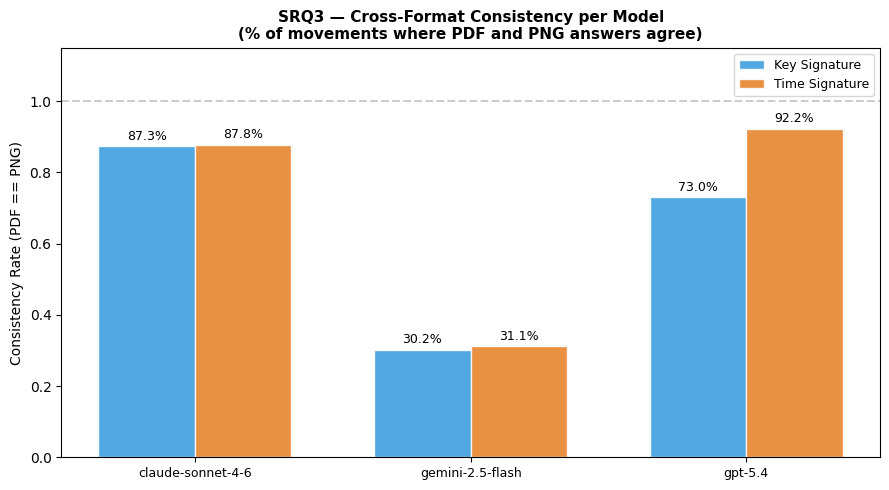


Saved to srq3_consistency.png and .csv

Note: consistency measures answer agreement across formats,
not correctness. A model can be consistently wrong.


In [15]:
print("=" * 65)
print("SRQ3 — Cross-Format Consistency (Definition B)")
print("Same answer on PDF and PNG? (regardless of correctness)")
print("=" * 65)

consistency_records = []

for model in MODELS:
    print(f"\n  {model}")
    for task in TASKS:
        df_pdf = df3[
            (df3["model"] == model) &
            (df3["question_type"] == task) &
            (df3["input_type"] == "pdf")
        ].set_index("piece_id")

        df_png = df3[
            (df3["model"] == model) &
            (df3["question_type"] == task) &
            (df3["input_type"] == "png")
        ].set_index("piece_id")

        shared = df_pdf.index.intersection(df_png.index)

        pdf_norm = df_pdf.loc[shared, "parsed_answer"].fillna("").apply(
            lambda x: normalise_for_sklearn(x, task))
        png_norm = df_png.loc[shared, "parsed_answer"].fillna("").apply(
            lambda x: normalise_for_sklearn(x, task))

        consistent = (pdf_norm == png_norm).sum()
        total      = len(shared)
        rate       = consistent / total if total > 0 else float("nan")

        print(f"    {task:<20}: {consistent}/{total} = {rate:.1%}")

        consistency_records.append({
            "model":            model,
            "task":             task,
            "n_shared":         int(total),
            "n_consistent":     int(consistent),
            "consistency_rate": round(rate, 4)
        })

consistency_df = pd.DataFrame(consistency_records)

# ── SUMMARY PER MODEL (averaged across tasks) ─────────────────────────────────
print("\n  Overall consistency per model (avg across tasks):")
model_avg = consistency_df.groupby("model")["consistency_rate"].mean()
for model, rate in model_avg.items():
    print(f"    {model:<25}: {rate:.1%}")

# ── PLOT ─────────────────────────────────────────────────────────────────────
pivot = consistency_df.pivot_table(
    index="model", columns="task",
    values="consistency_rate"
)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(pivot.index))
width = 0.35
colours = ["#3498db", "#e67e22"]

for k, (col, colour) in enumerate(zip(pivot.columns, colours)):
    bars = ax.bar(x + k * width, pivot[col], width,
                  label=col.replace("_", " ").title(),
                  color=colour, alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, pivot[col]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f"{val:.1%}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(pivot.index, fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Consistency Rate (PDF == PNG)", fontsize=10)
ax.set_title(
    "SRQ3 — Cross-Format Consistency per Model\n"
    "(% of movements where PDF and PNG answers agree)",
    fontsize=11, fontweight="bold"
)
ax.axhline(1.0, color="grey", linestyle="--", alpha=0.4)
ax.legend(fontsize=9)

plt.tight_layout()
out_path = RESULTS_DIR / "srq3_consistency.png"
plt.savefig(out_path, dpi=130, bbox_inches="tight")
plt.show()

consistency_df.to_csv(RESULTS_DIR / "srq3_consistency.csv", index=False)
print(f"\nSaved to srq3_consistency.png and .csv")
print("\nNote: consistency measures answer agreement across formats,")
print("not correctness. A model can be consistently wrong.")

---
## All outputs saved to `results/`

| File | Content |
|------|---------|
| `srq1_summary.csv` | Accuracy + P/R/F1 per model per task |
| `srq1_confusion_matrices.png` | Confusion matrices (SRQ1) |
| `srq1_per_class_accuracy.png/.csv` | Per-class accuracy (SRQ1) |
| `srq1_agreement.csv` | Cross-model agreement table |
| `srq3_summary.csv` | Accuracy + P/R/F1 per model per format per task |
| `srq3_mcnemar.csv` | McNemar test results |
| `srq3_format_direction.csv` | Format effect direction counts |
| `srq3_confusion_key_signature.png` | Confusion matrices, key sig |
| `srq3_confusion_time_signature.png` | Confusion matrices, time sig |
| `srq3_per_class_delta.png/.csv` | Per-class PNG−PDF delta |
| `srq3_consistency.png/.csv` | Cross-format consistency |
